# Students Social Media Addiction — EDA

Dataset: `Dataset/Students Social Media Addiction.csv`

## Contents
- Overview + data checks
- Usage, sleep, mental health, conflicts
- Academic impact + group comparisons
- Relationships + correlations

In [1]:
# Setup
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Plot styling (readable for non-technical audiences)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 110

DATA_PATH = os.path.join("..", "Dataset", "Students Social Media Addiction.csv")
print("Using dataset path:", DATA_PATH)

Using dataset path: ../Dataset/Students Social Media Addiction.csv


In [2]:
# Load data (works locally + on Kaggle)

from pathlib import Path

FILENAME = "Students Social Media Addiction.csv"

# Kaggle input (your dataset path)
KAGGLE_PATH_EXACT = "/kaggle/input/student-social-media-addiction-analysis-dataset/Students Social Media Addiction.csv"

candidate_paths = [
    # Local project paths
    DATA_PATH,
    os.path.join("..", "Dataset", FILENAME),
    os.path.join("Dataset", FILENAME),
    os.path.join(os.getcwd(), "Dataset", FILENAME),
    # Kaggle exact path
    KAGGLE_PATH_EXACT,
]

found_path = None
for p in candidate_paths:
    if os.path.exists(p):
        found_path = p
        break

# Kaggle fallback: search /kaggle/input for the filename
if found_path is None and os.path.exists("/kaggle/input"):
    matches = list(Path("/kaggle/input").rglob(FILENAME))
    if matches:
        found_path = str(matches[0])

if found_path is None:
    raise FileNotFoundError(
        "Could not find the dataset CSV. Checked: "
        + ", ".join(candidate_paths)
        + " (and searched /kaggle/input)"
    )

print("Loading:", found_path)
df = pd.read_csv(found_path)

print("Rows:", len(df))
print("Columns:", df.shape[1])
display(df.head(10))

Loading: /kaggle/input/student-social-media-addiction-analysis-dataset/Students Social Media Addiction.csv
Rows: 705
Columns: 13


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
5,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
7,8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8
8,9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5
9,10,21,Female,Graduate,South Korea,3.3,Instagram,No,7.0,7,In Relationship,1,4


## Column glossary

Dtype, example values, unique values (per column).

In [3]:
def column_glossary(data: pd.DataFrame, sample_n: int = 5) -> pd.DataFrame:
    rows = []
    for c in data.columns:
        s = data[c]
        rows.append(
            {
                "column": c,
                "dtype": str(s.dtype),
                "non_null": int(s.notna().sum()),
                "missing": int(s.isna().sum()),
                "unique": int(s.nunique(dropna=True)),
                "examples": ", ".join(map(str, s.dropna().astype(str).head(sample_n).tolist())),
            }
        )
    out = pd.DataFrame(rows).sort_values(["missing", "unique"], ascending=[False, True])
    return out

gloss = column_glossary(df)
display(gloss)

,column,dtype,non_null,missing,unique,examples
2,Gender,object,705,0,2,"Female, Male, Female, Male, Male"
7,Affects_Academic_Performance,object,705,0,2,"Yes, No, Yes, No, Yes"
3,Academic_Level,object,705,0,3,"Undergraduate, Graduate, Undergraduate, High S..."
10,Relationship_Status,object,705,0,3,"In Relationship, Single, Complicated, Single, ..."
9,Mental_Health_Score,int64,705,0,6,"6, 8, 5, 7, 6"
11,Conflicts_Over_Social_Media,int64,705,0,6,"3, 0, 4, 1, 2"
1,Age,int64,705,0,7,"19, 22, 20, 18, 21"
12,Addicted_Score,int64,705,0,8,"8, 3, 9, 4, 7"
6,Most_Used_Platform,object,705,0,12,"Instagram, Twitter, TikTok, YouTube, Facebook"
8,Sleep_Hours_Per_Night,float64,705,0,59,"6.5, 7.5, 5.0, 7.0, 6.0"


## Data quality checks

- Missing values
- Duplicate rows
- `Student_ID` uniqueness

In [4]:
# Missing values (table)
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing) == 0:
    print("No missing values detected.")
else:
    display(missing.to_frame("missing_count"))

# Duplicate rows
n_dupes = df.duplicated().sum()
print("Duplicate rows:", int(n_dupes))

# Student_ID uniqueness (if present)
if "Student_ID" in df.columns:
    print("Student_ID unique?", df["Student_ID"].is_unique)
    if not df["Student_ID"].is_unique:
        display(df[df["Student_ID"].duplicated(keep=False)].sort_values("Student_ID").head(20))

No missing values detected.
Duplicate rows: 0
Student_ID unique? True


## Target: `Addicted_Score`

- Distribution
- Low/Medium/High bands (quantiles)

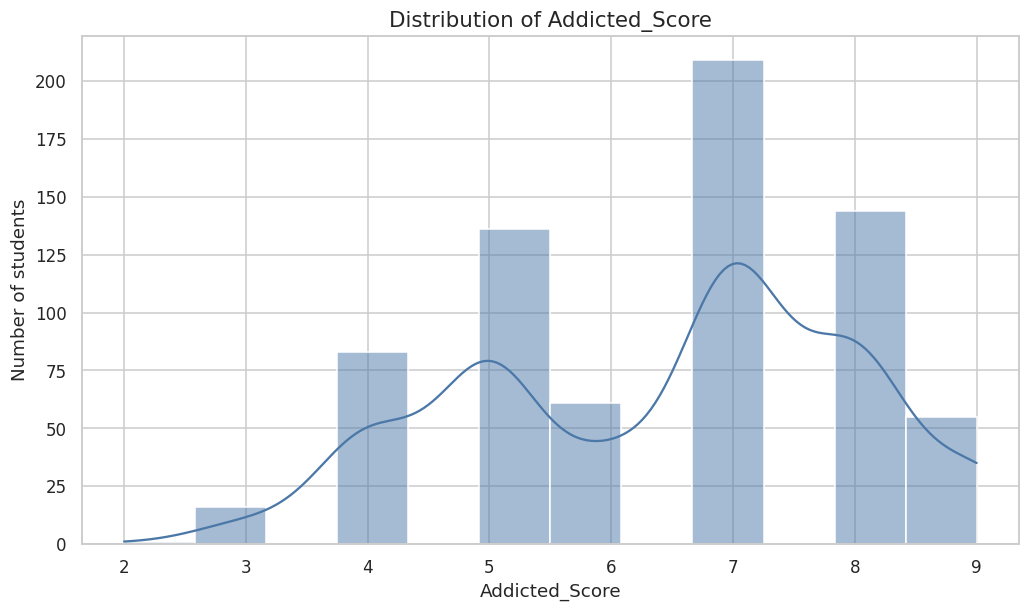

,students
Addiction_Band,
Low,236
Medium,270
High,199


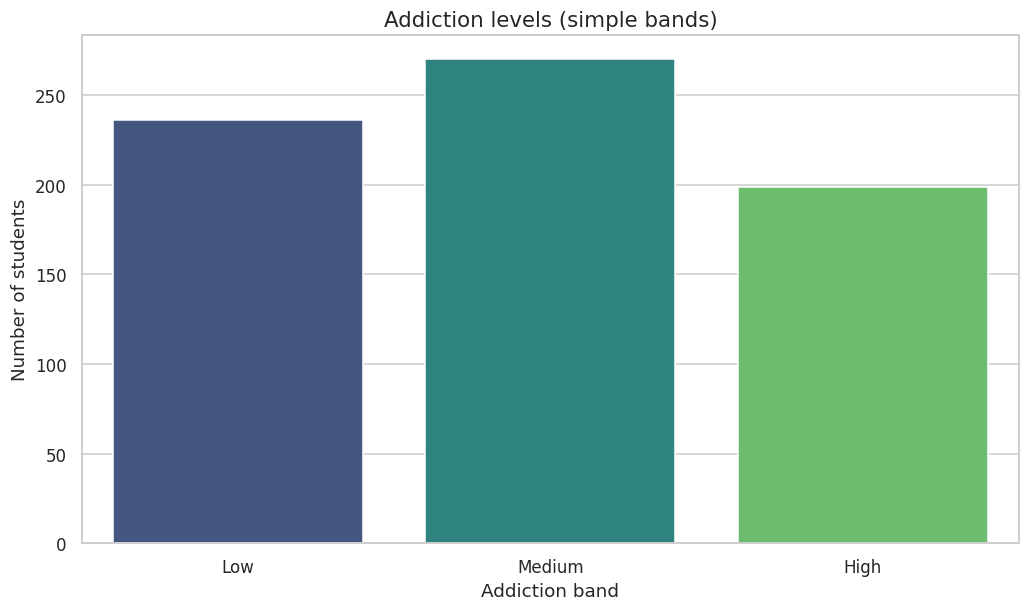

In [5]:
# Addicted_Score distribution + simple bands

if "Addicted_Score" not in df.columns:
    raise ValueError("Expected column Addicted_Score not found.")

score = df["Addicted_Score"].copy()

fig, ax = plt.subplots()
sns.histplot(score, bins=12, kde=True, ax=ax, color="#4C78A8")
ax.set_title("Distribution of Addicted_Score")
ax.set_xlabel("Addicted_Score")
ax.set_ylabel("Number of students")
plt.show()

# Create simple, explainable bands using quantiles (data-driven)
q1, q2 = score.quantile([0.33, 0.66]).tolist()

def addiction_band(x: float) -> str:
    if x <= q1:
        return "Low"
    if x <= q2:
        return "Medium"
    return "High"

df["Addiction_Band"] = score.map(addiction_band)

band_counts = df["Addiction_Band"].value_counts().reindex(["Low", "Medium", "High"])
display(band_counts.to_frame("students"))

fig, ax = plt.subplots()
sns.countplot(data=df, x="Addiction_Band", order=["Low", "Medium", "High"], ax=ax, palette="viridis")
ax.set_title("Addiction levels (simple bands)")
ax.set_xlabel("Addiction band")
ax.set_ylabel("Number of students")
plt.show()

## Prep (light)

- Fix dtypes
- Create `Usage_Band`

In [6]:
# Light cleanup / typing

df = df.copy()

# Expected columns (based on the CSV header)
NUM_COLS = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score",
]
CAT_COLS = [
    "Gender",
    "Academic_Level",
    "Country",
    "Most_Used_Platform",
    "Affects_Academic_Performance",
    "Relationship_Status",
]

# Coerce numerics safely
for c in NUM_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Normalize Yes/No field (keep original too)
if "Affects_Academic_Performance" in df.columns:
    df["Affects_Academic_Performance"] = df["Affects_Academic_Performance"].astype(str).str.strip()
    df["Affects_Academic_Performance_Flag"] = df["Affects_Academic_Performance"].map({"Yes": 1, "No": 0})

# Categories
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().astype("category")

# Simple usage bands (interpretability)
if "Avg_Daily_Usage_Hours" in df.columns:
    usage = df["Avg_Daily_Usage_Hours"].dropna()
    u1, u2 = usage.quantile([0.33, 0.66]).tolist()

    def usage_band(x: float) -> str:
        if pd.isna(x):
            return "Unknown"
        if x <= u1:
            return "Low"
        if x <= u2:
            return "Medium"
        return "High"

    df["Usage_Band"] = df["Avg_Daily_Usage_Hours"].map(usage_band).astype("category")

display(df.describe(include="all").T.head(20))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,705.0,NaN,NaN,NaN,353.0,203.660256,1.0,177.0,353.0,529.0,705.0
Age,705.0,NaN,NaN,NaN,20.659574,1.399217,18.0,19.0,21.0,22.0,24.0
Gender,705,2,Female,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,705,3,Undergraduate,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,705,110,India,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_Daily_Usage_Hours,705.0,NaN,NaN,NaN,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5
Most_Used_Platform,705,12,Instagram,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Affects_Academic_Performance,705,2,Yes,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours_Per_Night,705.0,NaN,NaN,NaN,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,NaN,NaN,NaN,6.22695,1.105055,4.0,5.0,6.0,7.0,9.0


## Demographics

Age, gender, academic level, top countries.

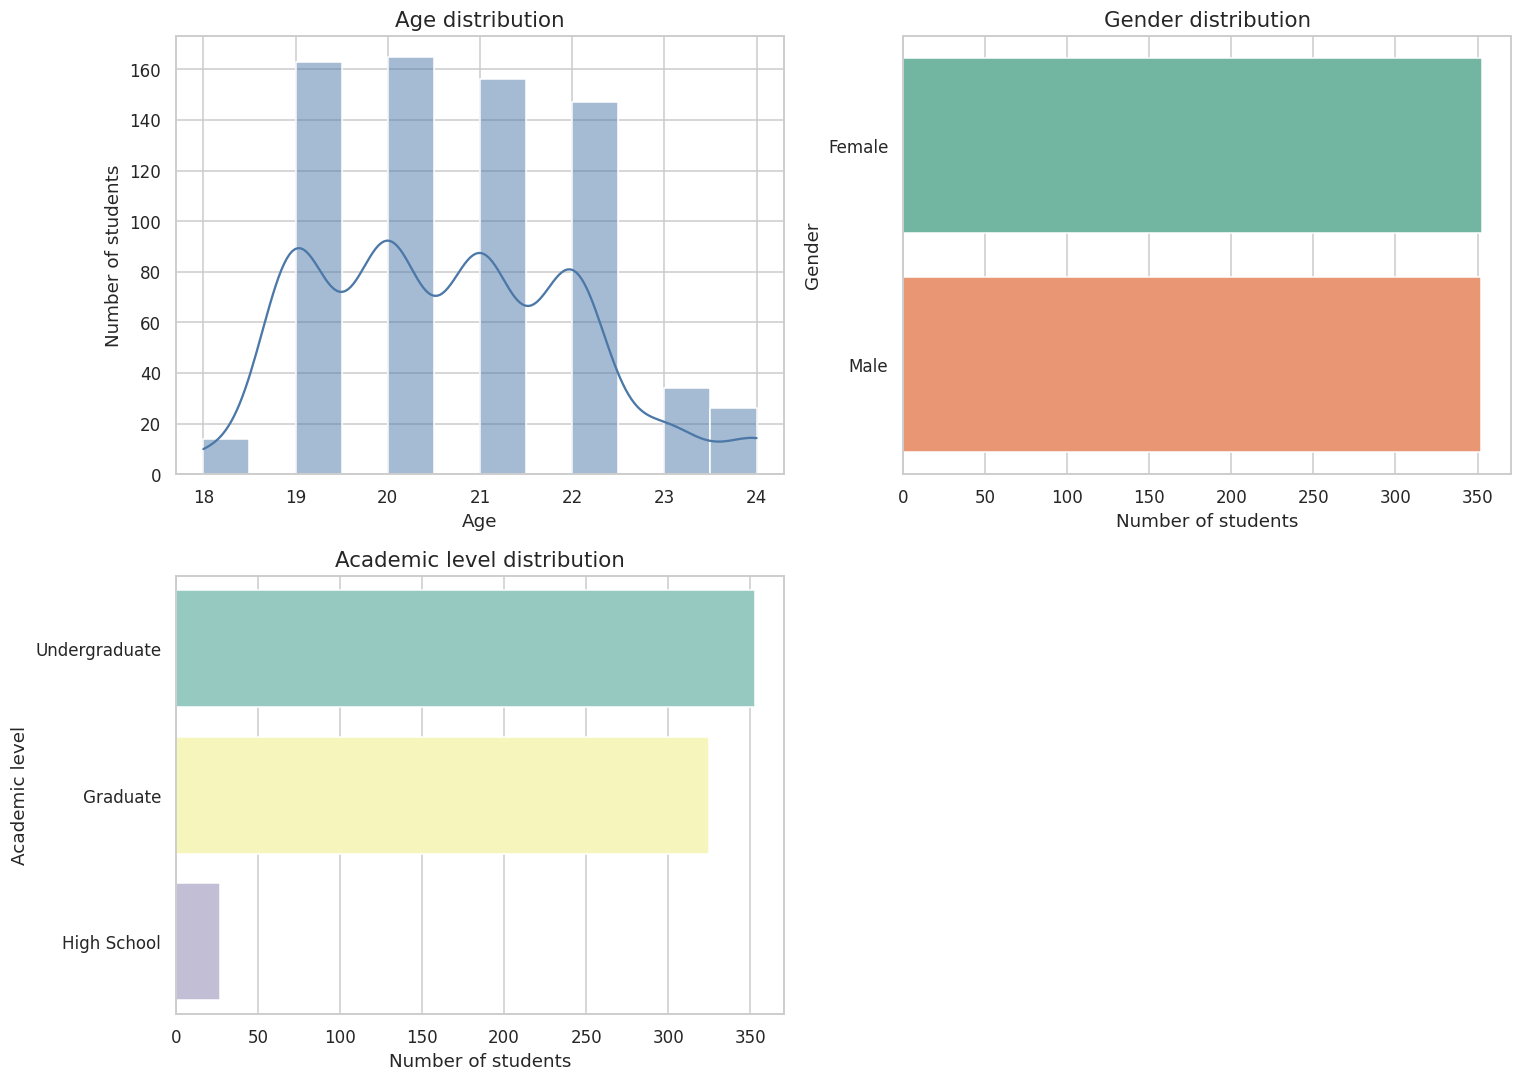

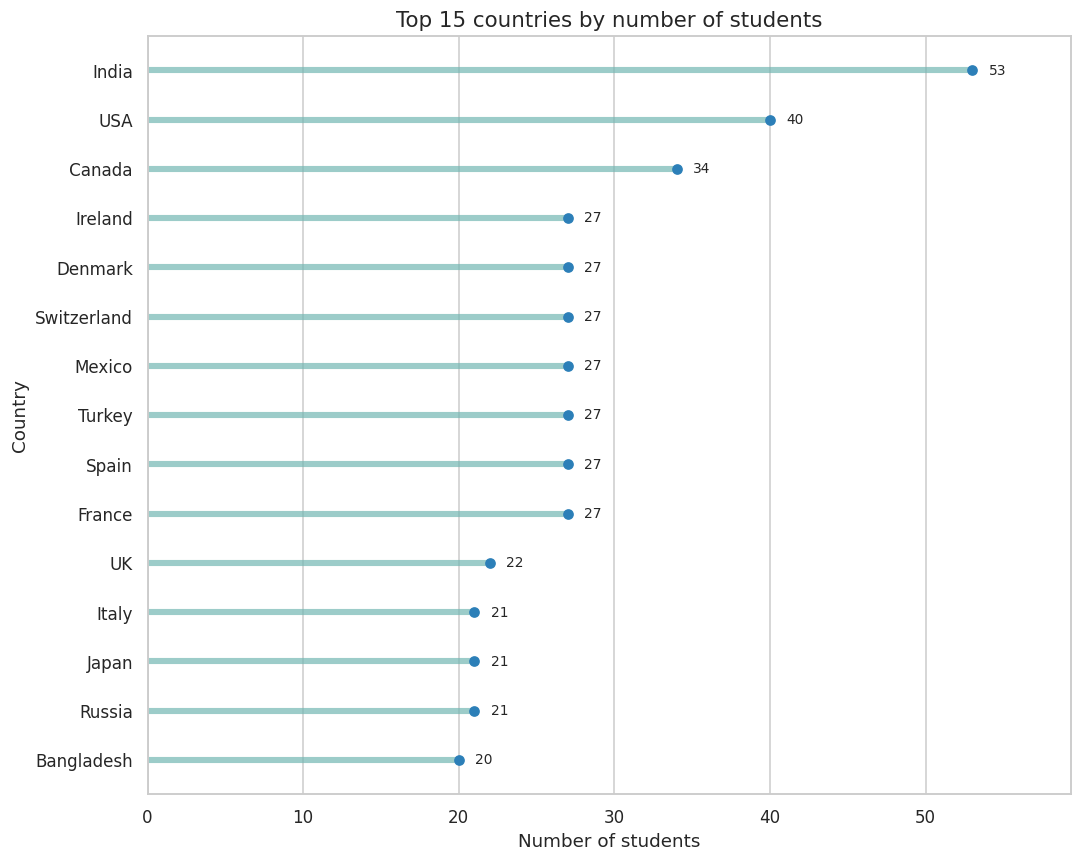

In [7]:
# Demographics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
if "Age" in df.columns:
    sns.histplot(df["Age"], bins=12, kde=True, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Age distribution")
    axes[0, 0].set_xlabel("Age")
    axes[0, 0].set_ylabel("Number of students")
else:
    axes[0, 0].axis("off")

# Gender
if "Gender" in df.columns:
    order = df["Gender"].value_counts().index
    sns.countplot(data=df, y="Gender", order=order, ax=axes[0, 1], palette="Set2")
    axes[0, 1].set_title("Gender distribution")
    axes[0, 1].set_xlabel("Number of students")
    axes[0, 1].set_ylabel("Gender")
else:
    axes[0, 1].axis("off")

# Academic level
if "Academic_Level" in df.columns:
    order = df["Academic_Level"].value_counts().index
    sns.countplot(data=df, y="Academic_Level", order=order, ax=axes[1, 0], palette="Set3")
    axes[1, 0].set_title("Academic level distribution")
    axes[1, 0].set_xlabel("Number of students")
    axes[1, 0].set_ylabel("Academic level")
else:
    axes[1, 0].axis("off")

# Top countries (separate figure for readability)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

if "Country" in df.columns:
    # Lollipop chart (cleaner than bars when labels are many)
    top_countries = (
        df["Country"].astype(str).value_counts().nlargest(15).sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.hlines(
        y=top_countries.index,
        xmin=0,
        xmax=top_countries.values,
        color="#72B7B2",
        linewidth=4,
        alpha=0.7,
    )
    ax.plot(top_countries.values, top_countries.index, "o", color="#2C7FB8")

    # Value labels
    pad = max(top_countries.values) * 0.02
    for x, y in zip(top_countries.values, top_countries.index):
        ax.text(x + pad, y, str(int(x)), va="center", fontsize=9)

    ax.set_title("Top 15 countries by number of students")
    ax.set_xlabel("Number of students")
    ax.set_ylabel("Country")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, max(top_countries.values) + pad * 6)
    plt.tight_layout()
    plt.show()

## Usage patterns

Usage hours + platforms (overall and by groups).

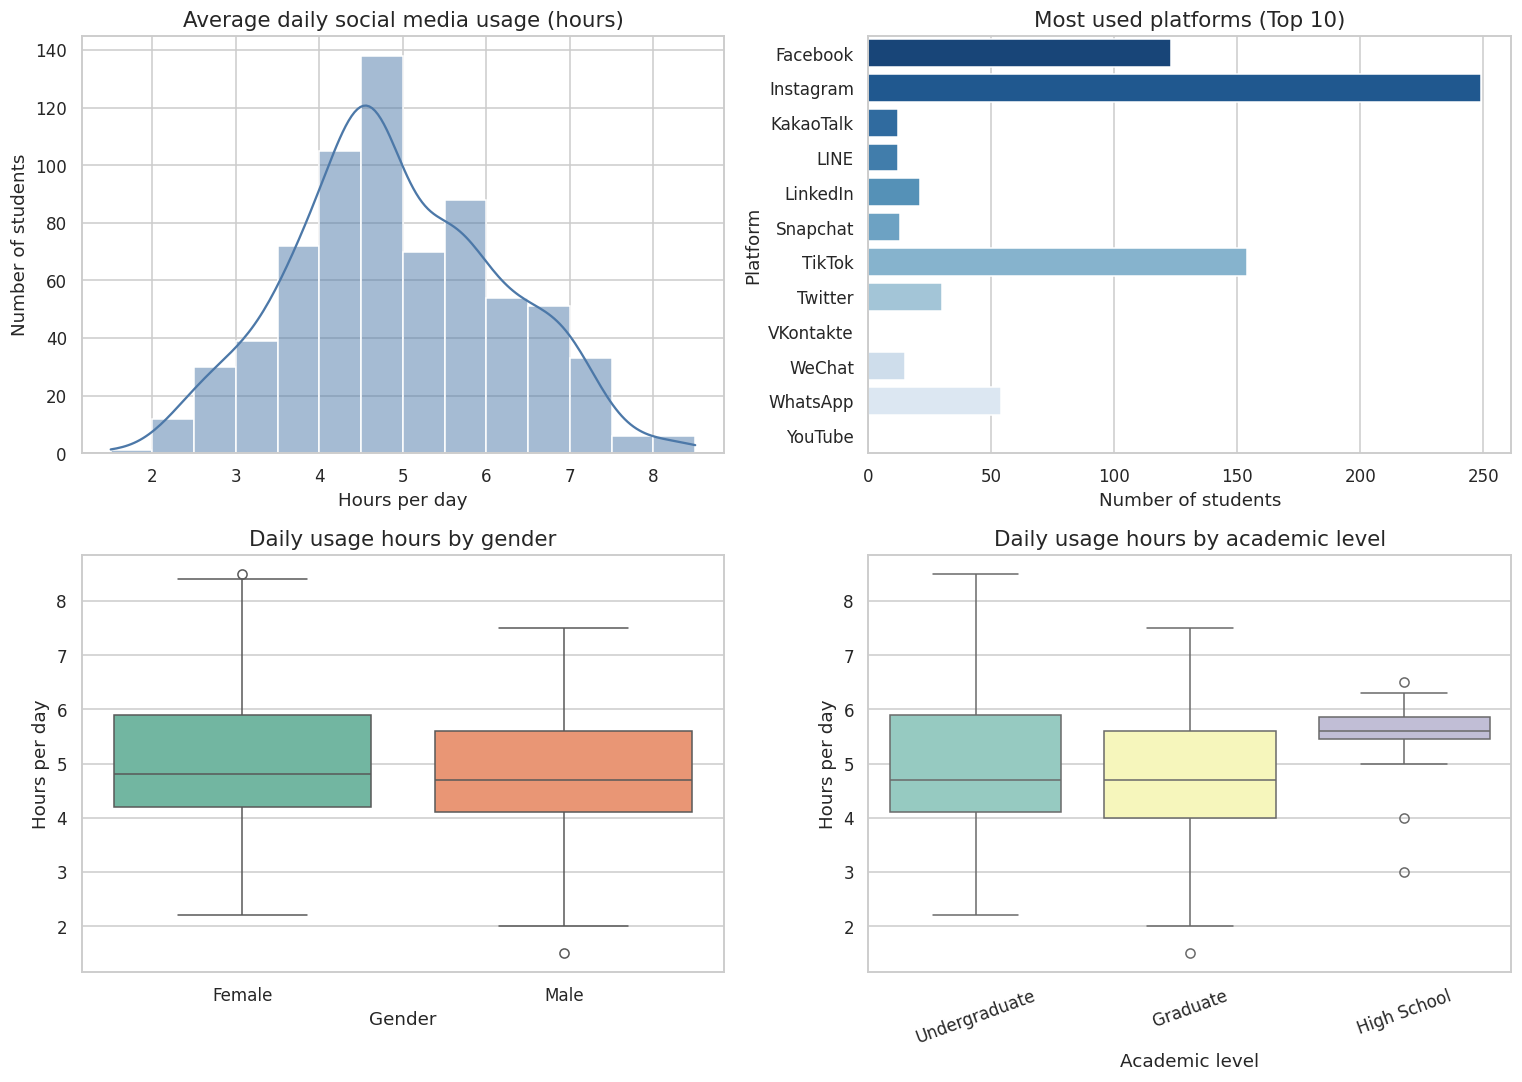

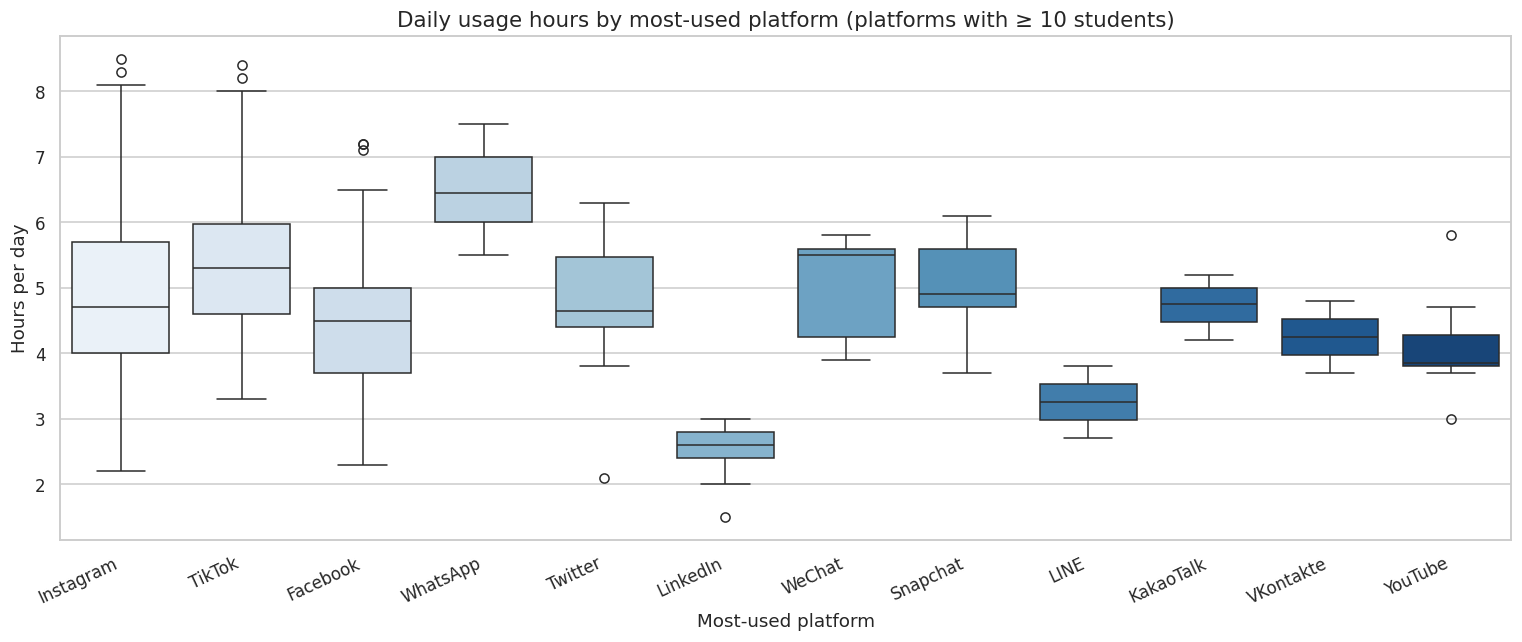

In [8]:
# Usage distribution + platforms

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Avg daily usage
if "Avg_Daily_Usage_Hours" in df.columns:
    sns.histplot(df["Avg_Daily_Usage_Hours"], bins=14, kde=True, ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Average daily social media usage (hours)")
    axes[0, 0].set_xlabel("Hours per day")
    axes[0, 0].set_ylabel("Number of students")
else:
    axes[0, 0].axis("off")

# Most used platform
if "Most_Used_Platform" in df.columns:
    top_platforms = df["Most_Used_Platform"].value_counts().head(10)
    sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[0, 1], palette="Blues_r")
    axes[0, 1].set_title("Most used platforms (Top 10)")
    axes[0, 1].set_xlabel("Number of students")
    axes[0, 1].set_ylabel("Platform")
else:
    axes[0, 1].axis("off")

# Usage by gender
if all(c in df.columns for c in ["Avg_Daily_Usage_Hours", "Gender"]):
    sns.boxplot(data=df, x="Gender", y="Avg_Daily_Usage_Hours", ax=axes[1, 0], palette="Set2")
    axes[1, 0].set_title("Daily usage hours by gender")
    axes[1, 0].set_xlabel("Gender")
    axes[1, 0].set_ylabel("Hours per day")
else:
    axes[1, 0].axis("off")

# Usage by academic level
if all(c in df.columns for c in ["Avg_Daily_Usage_Hours", "Academic_Level"]):
    order = df["Academic_Level"].value_counts().index
    sns.boxplot(data=df, x="Academic_Level", y="Avg_Daily_Usage_Hours", order=order, ax=axes[1, 1], palette="Set3")
    axes[1, 1].set_title("Daily usage hours by academic level")
    axes[1, 1].set_xlabel("Academic level")
    axes[1, 1].set_ylabel("Hours per day")
    axes[1, 1].tick_params(axis="x", rotation=20)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Usage by platform (boxplot) — only show platforms with enough samples
if all(c in df.columns for c in ["Avg_Daily_Usage_Hours", "Most_Used_Platform"]):
    counts = df["Most_Used_Platform"].value_counts()
    keep = counts[counts >= 10].index
    tmp = df[df["Most_Used_Platform"].isin(keep)].copy()

    plt.figure(figsize=(14, 6))
    order = tmp["Most_Used_Platform"].value_counts().index
    sns.boxplot(data=tmp, x="Most_Used_Platform", y="Avg_Daily_Usage_Hours", order=order, palette="Blues")
    plt.title("Daily usage hours by most-used platform (platforms with ≥ 10 students)")
    plt.xlabel("Most-used platform")
    plt.ylabel("Hours per day")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## Well-being

Sleep, mental health, and conflicts.

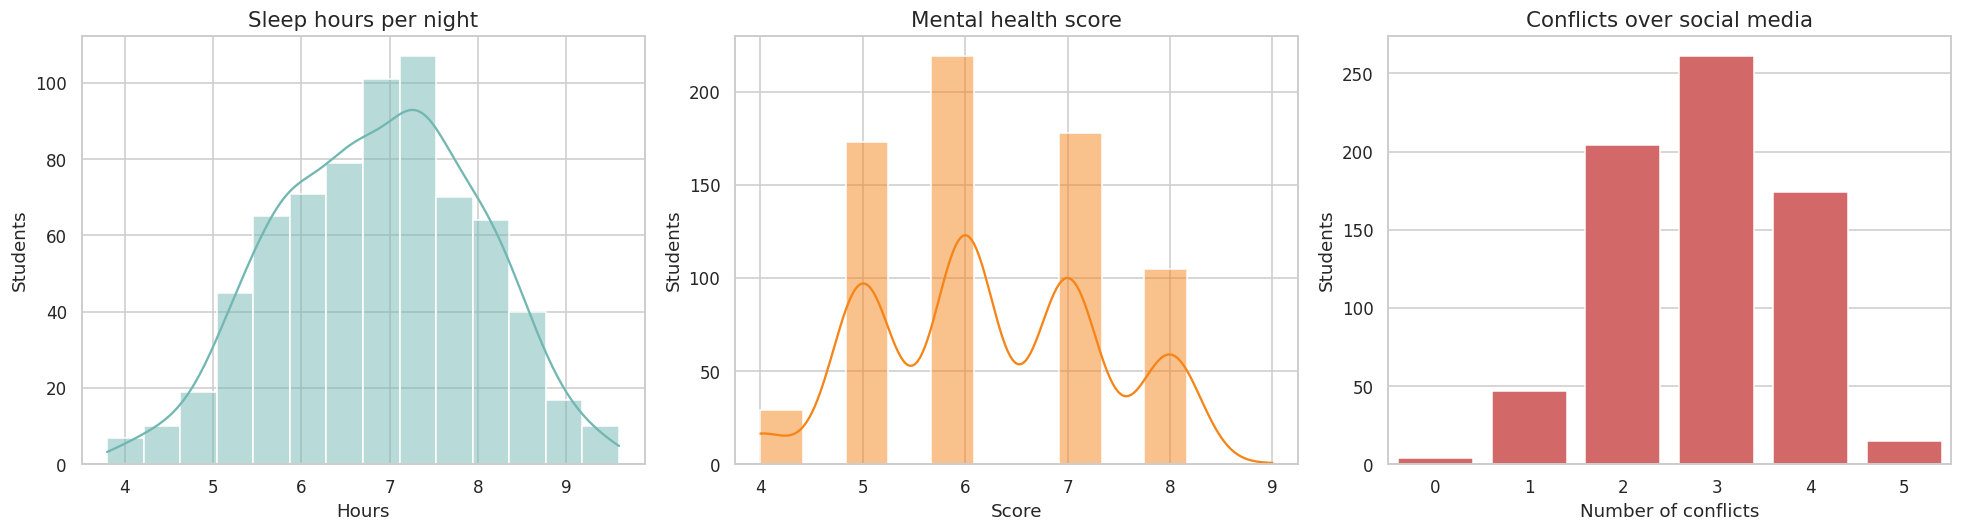

,count,mean,std,min,25%,50%,75%,max
Age,705.0,20.659574,1.399217,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,705.0,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,705.0,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,6.226950,1.105055,4.0,5.0,6.0,7.0,9.0
Conflicts_Over_Social_Media,705.0,2.849645,0.957968,0.0,2.0,3.0,4.0,5.0
Addicted_Score,705.0,6.436879,1.587165,2.0,5.0,7.0,8.0,9.0


In [9]:
# Well-being distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if "Sleep_Hours_Per_Night" in df.columns:
    sns.histplot(df["Sleep_Hours_Per_Night"], bins=14, kde=True, ax=axes[0], color="#72B7B2")
    axes[0].set_title("Sleep hours per night")
    axes[0].set_xlabel("Hours")
    axes[0].set_ylabel("Students")
else:
    axes[0].axis("off")

if "Mental_Health_Score" in df.columns:
    sns.histplot(df["Mental_Health_Score"], bins=12, kde=True, ax=axes[1], color="#F58518")
    axes[1].set_title("Mental health score")
    axes[1].set_xlabel("Score")
    axes[1].set_ylabel("Students")
else:
    axes[1].axis("off")

if "Conflicts_Over_Social_Media" in df.columns:
    sns.countplot(x="Conflicts_Over_Social_Media", data=df, ax=axes[2], color="#E45756")
    axes[2].set_title("Conflicts over social media")
    axes[2].set_xlabel("Number of conflicts")
    axes[2].set_ylabel("Students")
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()

# Summary table (easy to read)
display(df[NUM_COLS].describe().T)

## Academic impact

`Affects_Academic_Performance` (Yes/No) + metric comparisons.

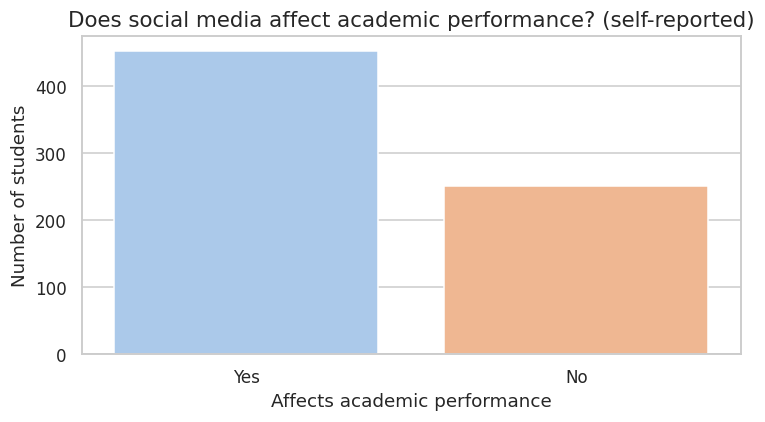

Avg_Daily_Usage_Hours               \
                                              mean median count   
Affects_Academic_Performance                                      
No                                            3.80    3.9   252   
Yes                                           5.54    5.5   453   

                             Sleep_Hours_Per_Night               \
                                              mean median count   
Affects_Academic_Performance                                      
No                                            7.81   7.75   252   
Yes                                           6.34   6.30   453   

                             Mental_Health_Score               \
                                            mean median count   
Affects_Academic_Performance                                    
No                                          7.42    7.0   252   
Yes                                         5.56    6.0   453   

                             Conflicts_Over_Social_Media               \
                                                    mean median count   
Affects_Academic_Performance                                            
No                                                  1.78    2.0   252   
Yes                                                 3.44    3.0   453   

                             Addicted_Score               
                                       mean median count  
Affects_Academic_Performance                              
No                                     4.60    5.0   252  
Yes                                    7.46    7.0   453

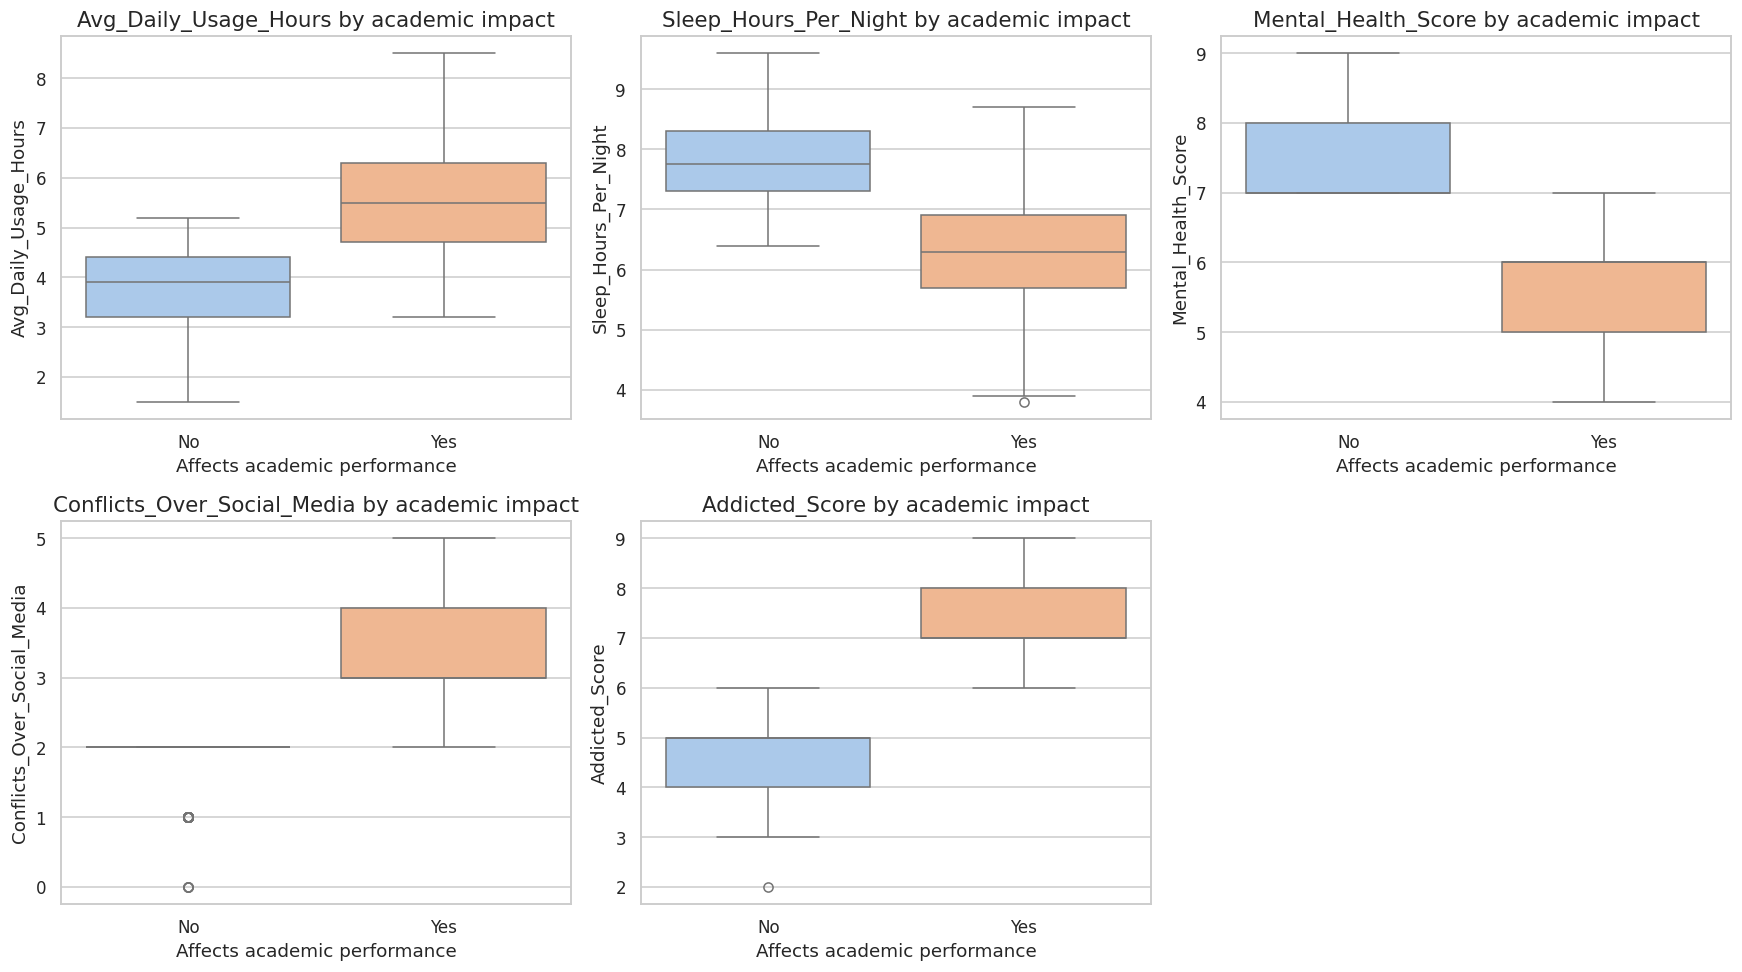

In [10]:
# Academic impact: counts + group comparisons

if "Affects_Academic_Performance" in df.columns:
    plt.figure(figsize=(7, 4))
    order = df["Affects_Academic_Performance"].value_counts().index
    sns.countplot(data=df, x="Affects_Academic_Performance", order=order, palette="pastel")
    plt.title("Does social media affect academic performance? (self-reported)")
    plt.xlabel("Affects academic performance")
    plt.ylabel("Number of students")
    plt.tight_layout()
    plt.show()

    # Compare key numeric metrics by Yes/No
    compare_cols = [
        "Avg_Daily_Usage_Hours",
        "Sleep_Hours_Per_Night",
        "Mental_Health_Score",
        "Conflicts_Over_Social_Media",
        "Addicted_Score",
    ]
    compare_cols = [c for c in compare_cols if c in df.columns]

    tmp = df.dropna(subset=["Affects_Academic_Performance"]).copy()

    # Summary table
    summary = (
        tmp.groupby("Affects_Academic_Performance")[compare_cols]
        .agg(["mean", "median", "count"])
        .round(2)
    )
    display(summary)

    # Visual comparisons
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for i, c in enumerate(compare_cols):
        ax = axes[i]
        sns.boxplot(data=tmp, x="Affects_Academic_Performance", y=c, ax=ax, palette="pastel")
        ax.set_title(f"{c} by academic impact")
        ax.set_xlabel("Affects academic performance")
        ax.set_ylabel(c)

    # Hide unused subplots
    for j in range(len(compare_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Column Affects_Academic_Performance not found.")

## Relationships

`Addicted_Score` vs usage, sleep, mental health, conflicts.

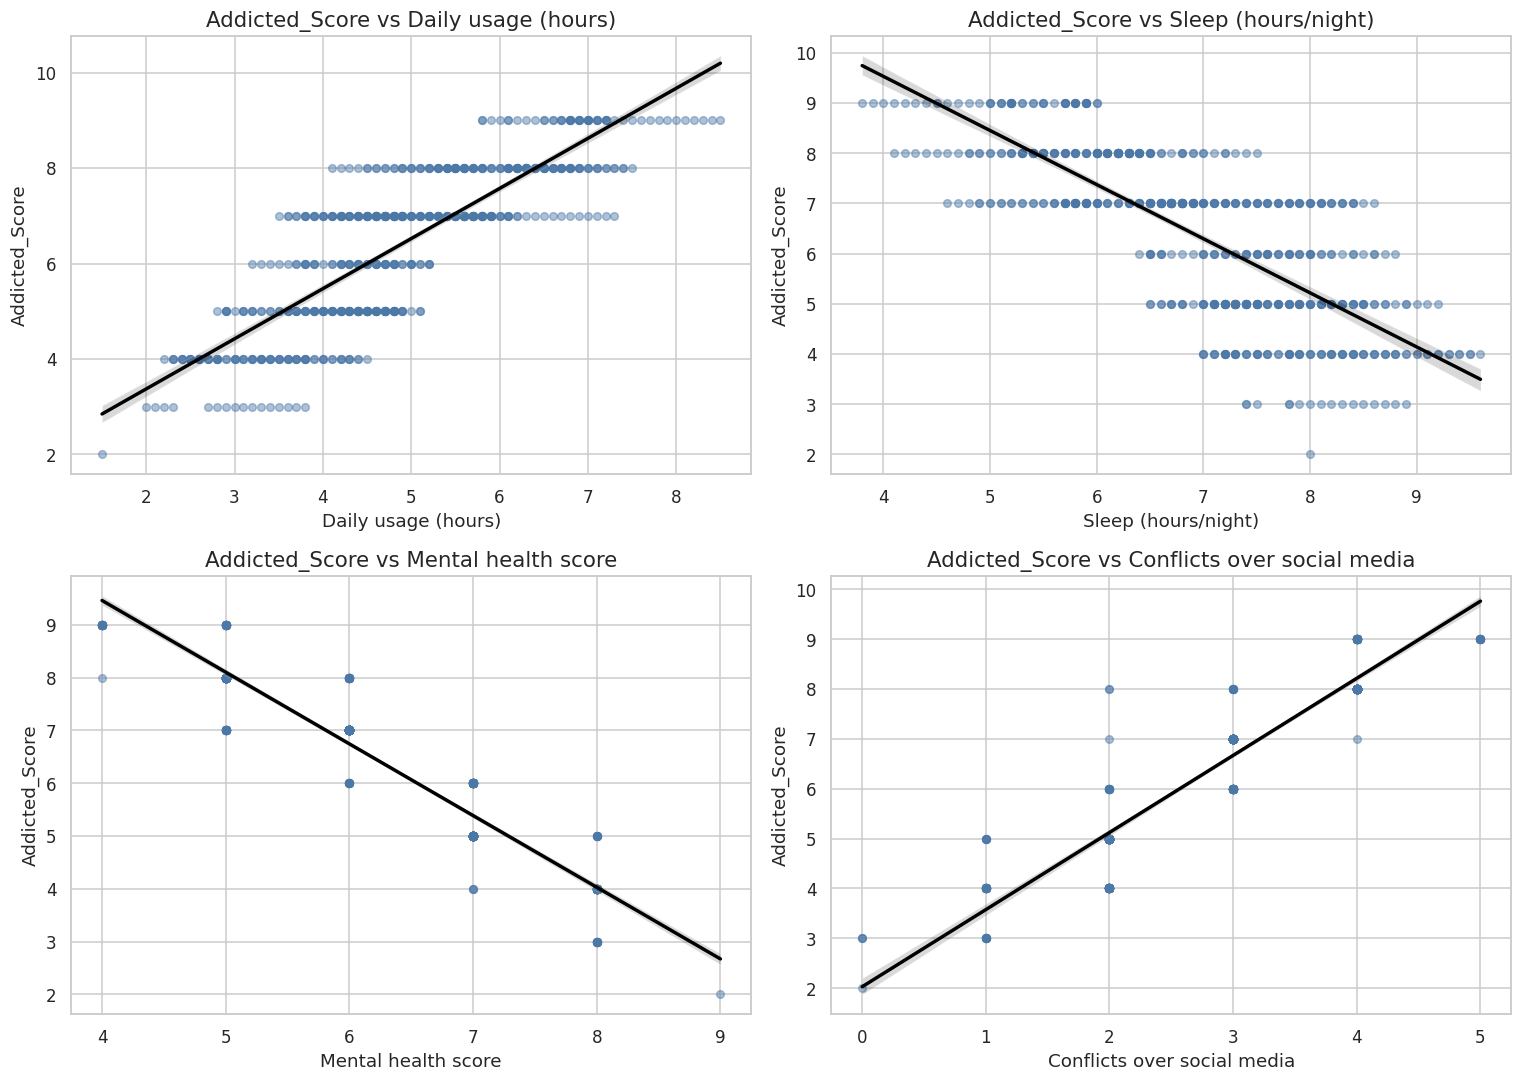

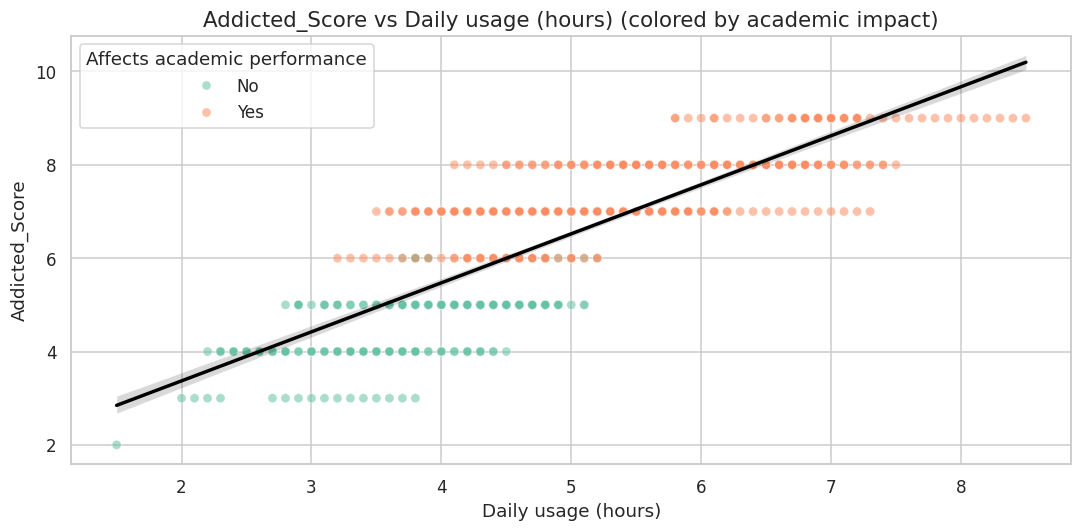

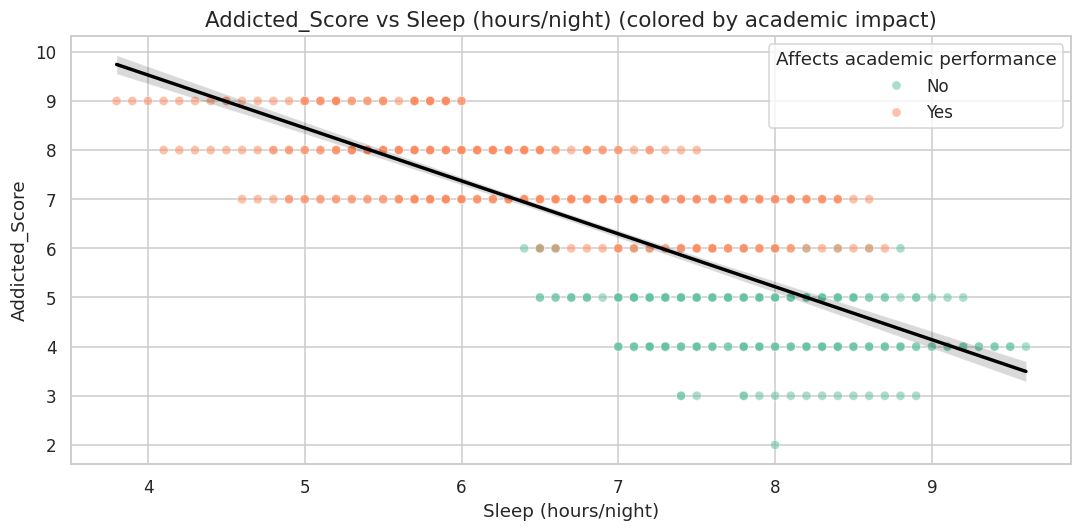

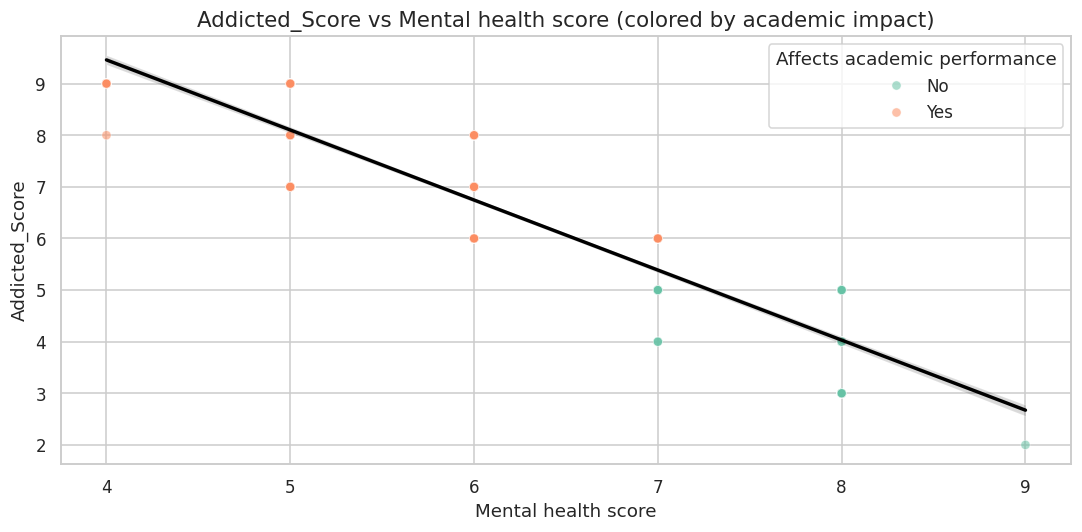

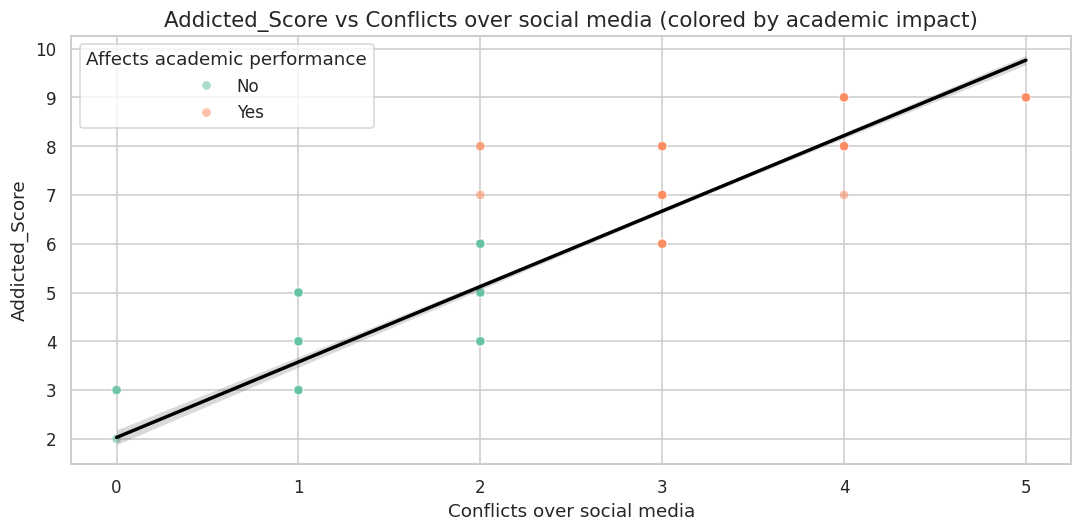

In [11]:
# Relationships with Addicted_Score

rel_pairs = [
    ("Avg_Daily_Usage_Hours", "Daily usage (hours)"),
    ("Sleep_Hours_Per_Night", "Sleep (hours/night)"),
    ("Mental_Health_Score", "Mental health score"),
    ("Conflicts_Over_Social_Media", "Conflicts over social media"),
]

available = [(c, label) for c, label in rel_pairs if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (c, label) in enumerate(available[:4]):
    ax = axes[i]
    sns.regplot(
        data=df,
        x=c,
        y="Addicted_Score",
        ax=ax,
        scatter_kws={"alpha": 0.45, "s": 25},
        line_kws={"color": "black"},
        color="#4C78A8",
    )
    ax.set_title(f"Addicted_Score vs {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Addicted_Score")

# Hide unused subplots if any
for j in range(len(available), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Same relationships, but split by academic impact (if available)
if "Affects_Academic_Performance" in df.columns:
    for c, label in available:
        plt.figure(figsize=(10, 5))
        sns.scatterplot(
            data=df,
            x=c,
            y="Addicted_Score",
            hue="Affects_Academic_Performance",
            alpha=0.55,
            palette="Set2",
        )
        sns.regplot(data=df, x=c, y="Addicted_Score", scatter=False, color="black")
        plt.title(f"Addicted_Score vs {label} (colored by academic impact)")
        plt.xlabel(label)
        plt.ylabel("Addicted_Score")
        plt.legend(title="Affects academic performance")
        plt.tight_layout()
        plt.show()

## Correlations

Numeric correlation heatmap (+ sampled pairplot).

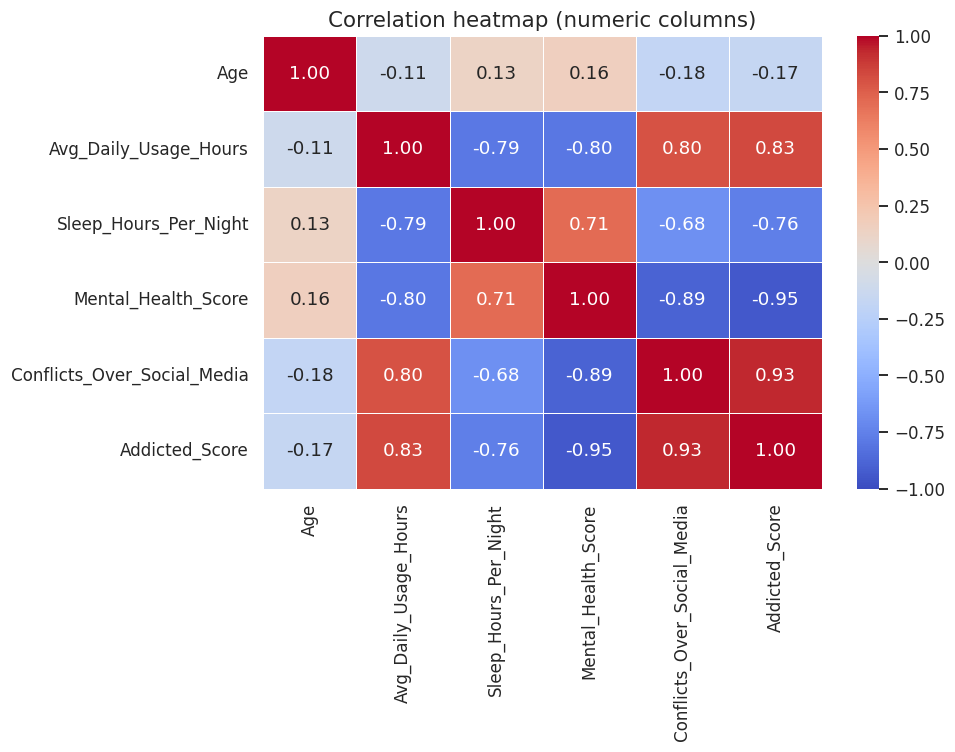

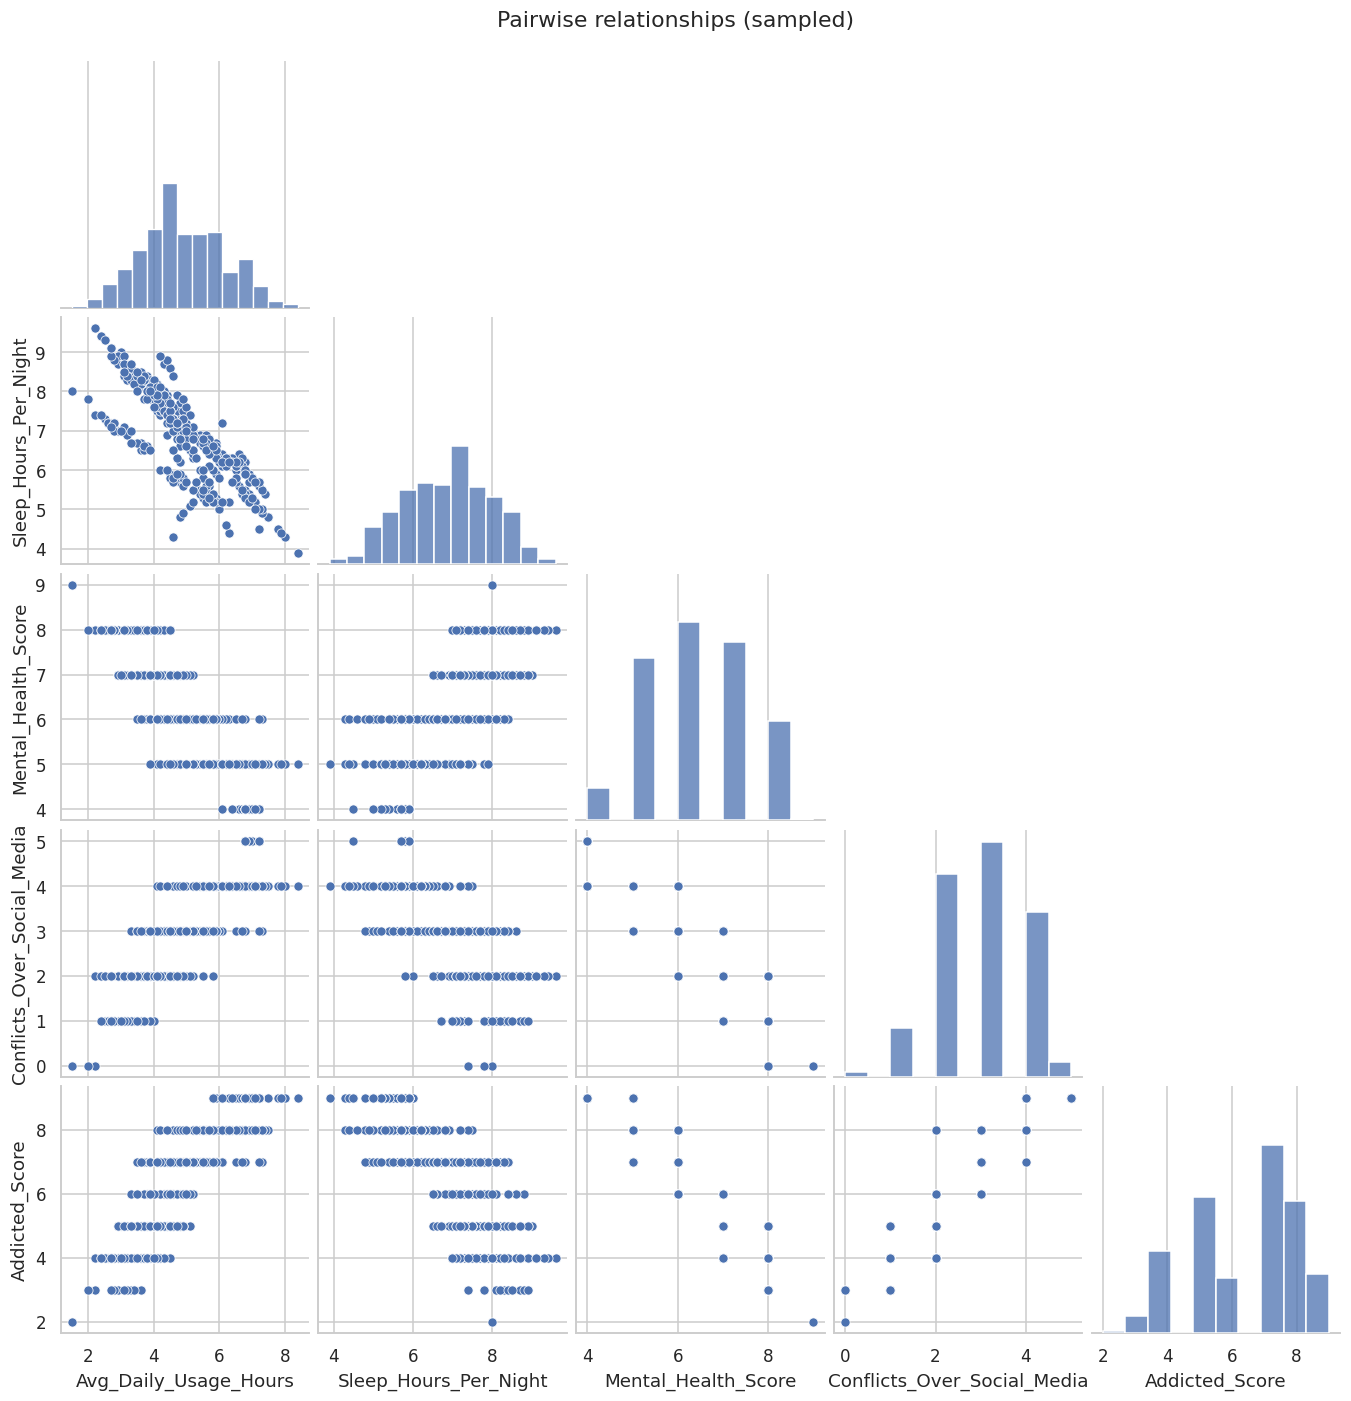

In [12]:
# Correlation heatmap

num = df[[c for c in NUM_COLS if c in df.columns]].copy()
corr = num.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlation heatmap (numeric columns)")
plt.tight_layout()
plt.show()

# Optional: pairplot (can be slow in some environments)
cols_for_pairplot = [
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score",
]
cols_for_pairplot = [c for c in cols_for_pairplot if c in df.columns]

sample = df[cols_for_pairplot].dropna()
if len(sample) > 400:
    sample = sample.sample(400, random_state=42)

sns.pairplot(sample, corner=True, diag_kind="hist")
plt.suptitle("Pairwise relationships (sampled)", y=1.02)
plt.show()

## Group comparisons

`Addicted_Score` by gender, academic level, platform, relationship status (+ top countries).

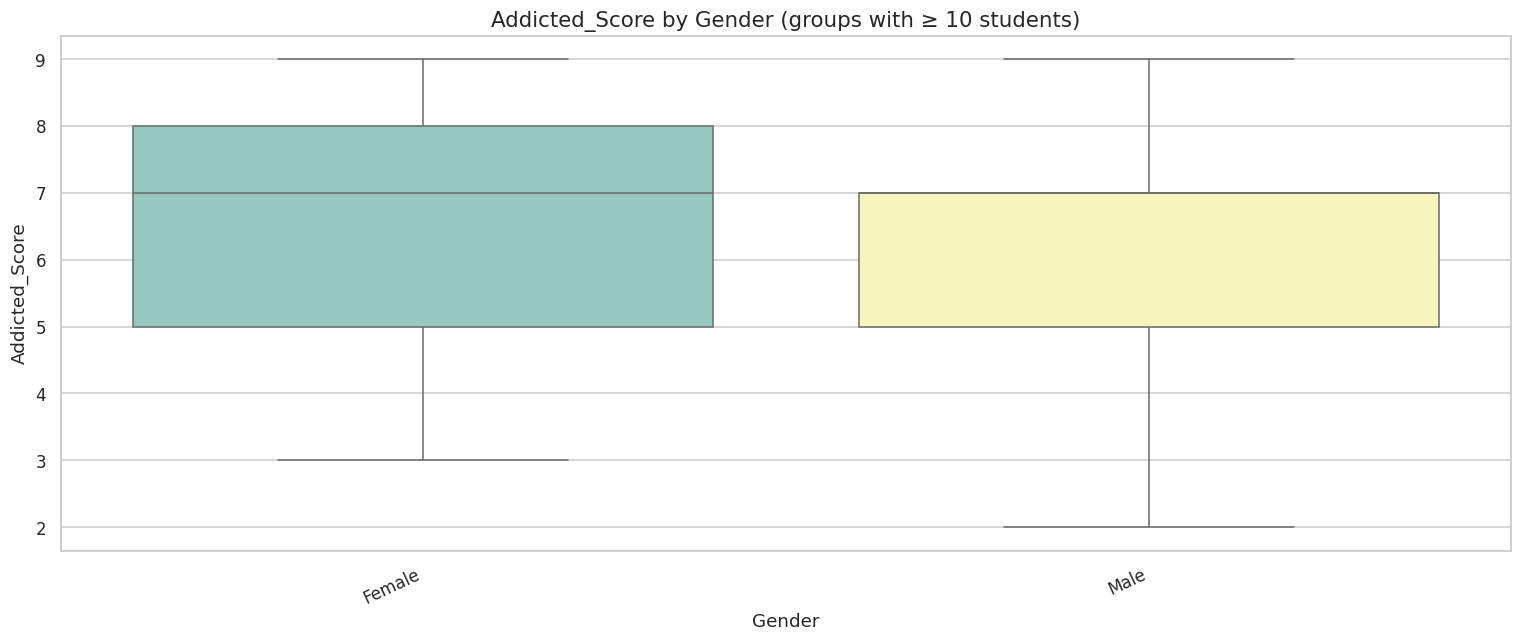

,mean,median,count
Gender,,,
Female,6.52,7.0,353
Male,6.36,7.0,352


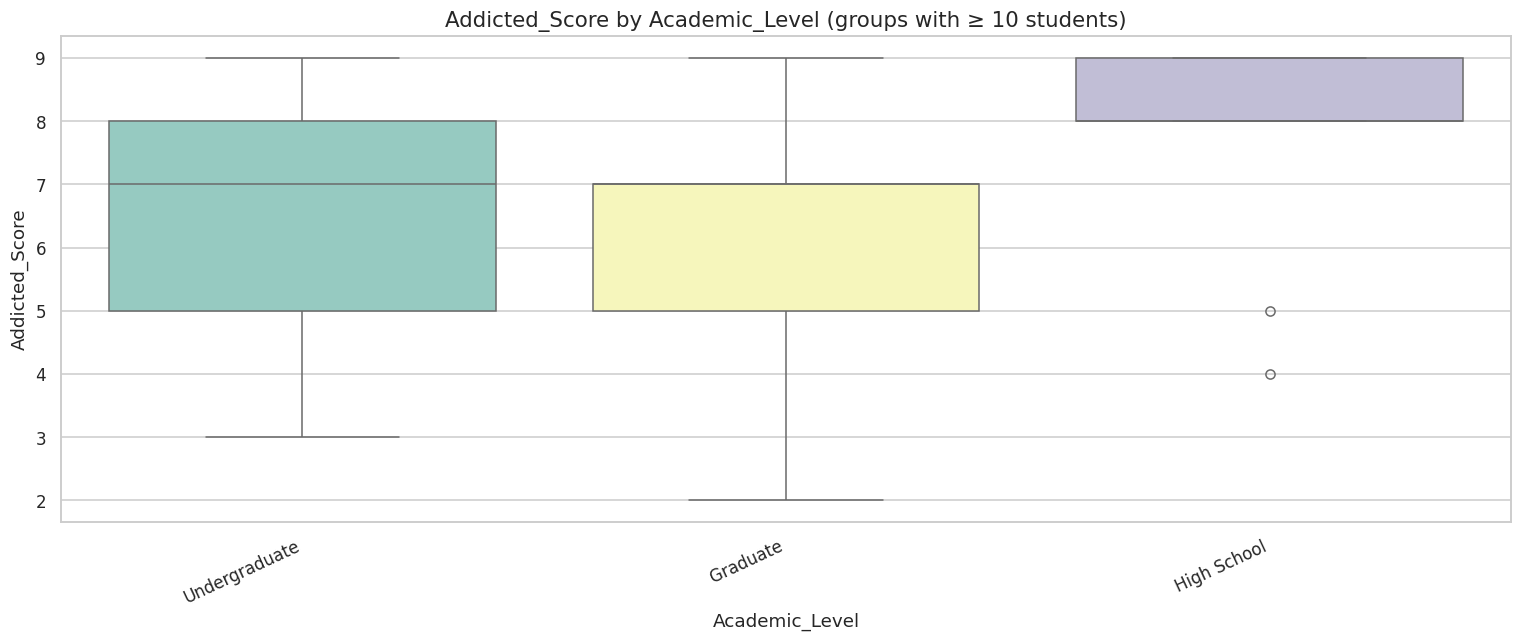

,mean,median,count
Academic_Level,,,
High School,8.04,8.0,27
Undergraduate,6.49,7.0,353
Graduate,6.24,7.0,325


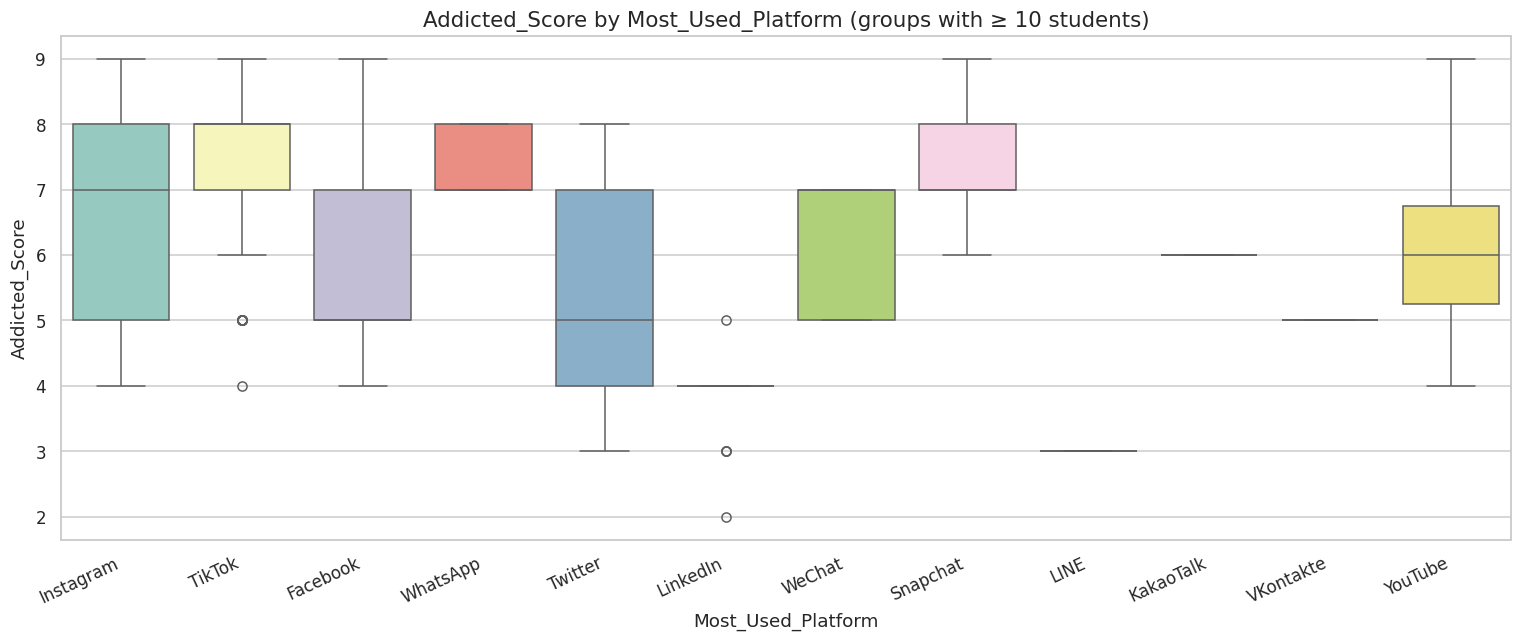

,mean,median,count
Most_Used_Platform,,,
WhatsApp,7.46,7.0,54
Snapchat,7.46,7.0,13
TikTok,7.43,8.0,154
Instagram,6.55,7.0,249
YouTube,6.10,6.0,10
WeChat,6.07,7.0,15
KakaoTalk,6.00,6.0,12
Facebook,5.67,5.0,123
Twitter,5.50,5.0,30


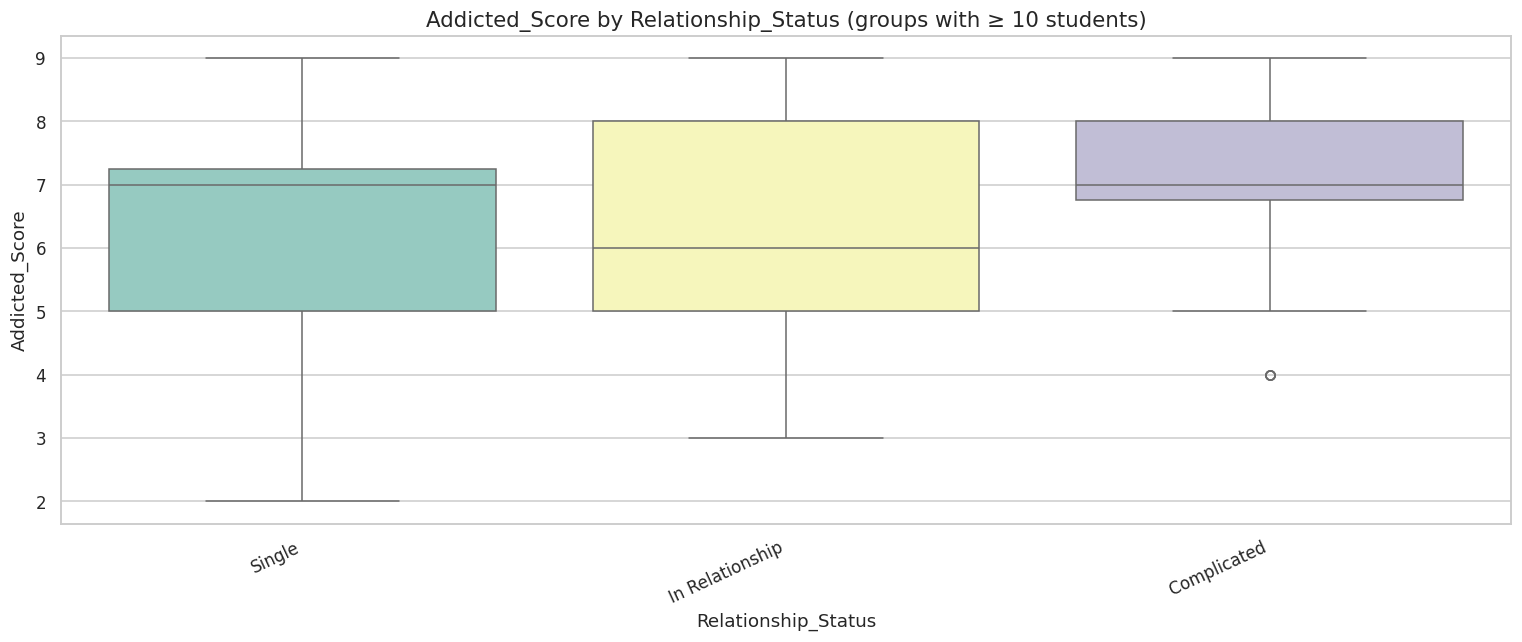

,mean,median,count
Relationship_Status,,,
Complicated,7.03,7.0,32
Single,6.46,7.0,384
In Relationship,6.34,6.0,289


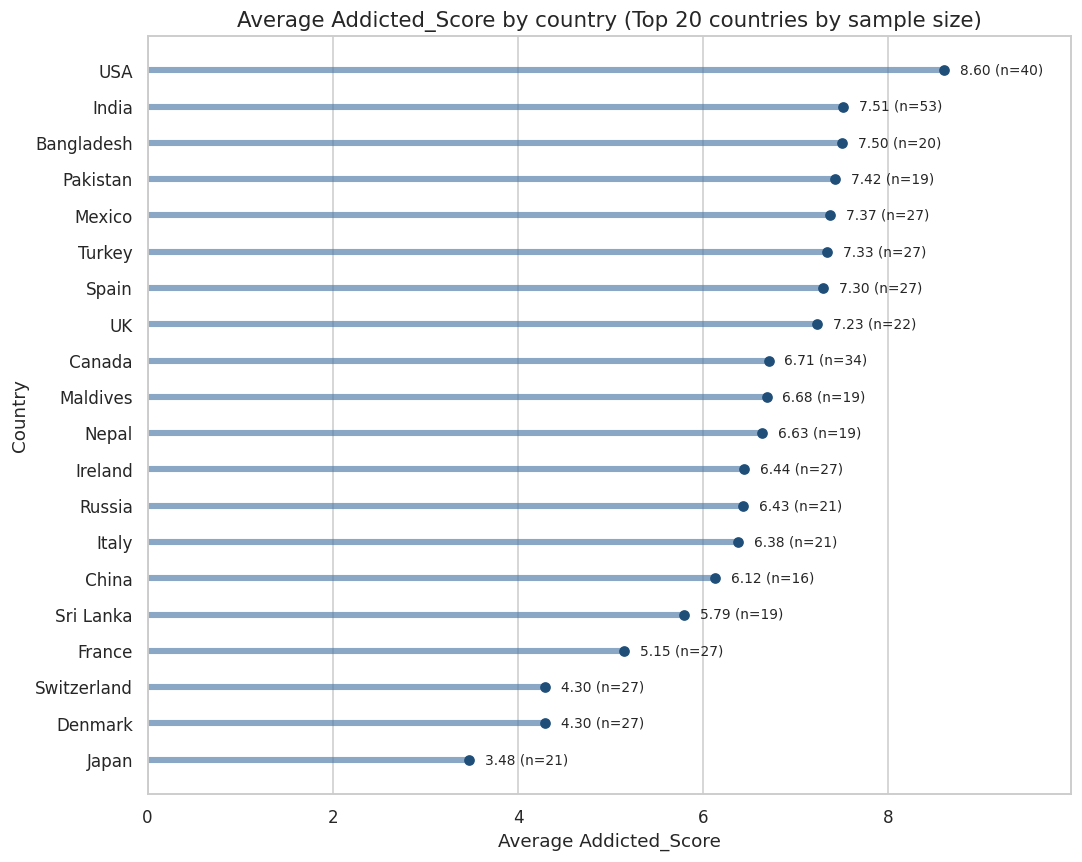

,mean,students
Country_str,,
India,7.51,53
USA,8.60,40
Canada,6.71,34
Mexico,7.37,27
Turkey,7.33,27
Spain,7.30,27
Ireland,6.44,27
France,5.15,27
Denmark,4.30,27


In [13]:
# Addicted_Score by groups

# Note: `title=None` keeps this compatible with older Python versions.
def boxplot_group(data: pd.DataFrame, group_col: str, value_col: str, min_count: int = 10, title=None):
    if group_col not in data.columns or value_col not in data.columns:
        print(f"Missing columns for plot: {group_col}, {value_col}")
        return

    counts = data[group_col].value_counts()
    keep = counts[counts >= min_count].index
    tmp = data[data[group_col].isin(keep)].copy()
    order = tmp[group_col].value_counts().index

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=tmp, x=group_col, y=value_col, order=order, palette="Set3")
    plt.title(title or f"{value_col} by {group_col} (groups with ≥ {min_count} students)")
    plt.xlabel(group_col)
    plt.ylabel(value_col)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    # Show group means with sample size
    stats = (
        tmp.groupby(group_col)[value_col]
        .agg(mean="mean", median="median", count="count")
        .sort_values("mean", ascending=False)
        .round(2)
    )
    display(stats)

for g in ["Gender", "Academic_Level", "Most_Used_Platform", "Relationship_Status"]:
    if g in df.columns:
        boxplot_group(df, g, "Addicted_Score", min_count=10)

# Countries: top by sample size, then average addiction
if "Country" in df.columns:
    # IMPORTANT: if Country is categorical, pandas `groupby` can include *unobserved* categories
    # which creates many extra labels. We avoid that by removing unused categories and/or using observed=True.
    country_counts = df["Country"].astype(str).value_counts()
    top = country_counts.head(20).index.tolist()

    tmp = df[df["Country"].astype(str).isin(top)].copy()

    # Compact stats table for plotting
    country_stats = (
        tmp.assign(Country_str=tmp["Country"].astype(str))
        .groupby("Country_str", observed=True)["Addicted_Score"]
        .agg(mean="mean", students="size")
        .sort_values("mean")
    )

    # Lollipop chart (cleaner than bars)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.hlines(
        y=country_stats.index,
        xmin=0,
        xmax=country_stats["mean"].values,
        color="#4C78A8",
        linewidth=4,
        alpha=0.65,
    )
    ax.plot(country_stats["mean"].values, country_stats.index, "o", color="#1F4E79")

    # Labels (mean + n)
    pad = max(country_stats["mean"].max() * 0.02, 0.05)
    for mean, y, n in zip(country_stats["mean"].values, country_stats.index, country_stats["students"].values):
        ax.text(mean + pad, y, f"{mean:.2f} (n={int(n)})", va="center", fontsize=9)

    ax.set_title("Average Addicted_Score by country (Top 20 countries by sample size)")
    ax.set_xlabel("Average Addicted_Score")
    ax.set_ylabel("Country")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, country_stats["mean"].max() + pad * 8)
    plt.tight_layout()
    plt.show()

    # Display table (sorted by sample size, then mean)
    display(
        country_stats.sort_values(["students", "mean"], ascending=[False, False]).round(2)
    )

## Summary tables

Metrics by `Addiction_Band` and `Usage_Band` (+ crosstab).

Avg_Daily_Usage_Hours              Sleep_Hours_Per_Night  \
                                mean median count                  mean   
Addiction_Band                                                            
High                            6.26    6.3   199                  5.73   
Low                             3.76    3.8   236                  7.84   
Medium                          4.94    4.8   270                  6.86   

                            Mental_Health_Score               \
               median count                mean median count   
Addiction_Band                                                 
High              5.8   199                4.97    5.0   199   
Low               7.8   236                7.45    7.0   236   
Medium            6.8   270                6.08    6.0   270   

               Conflicts_Over_Social_Media              Addicted_Score         \
                                      mean median count           mean median   
Addiction_Band                                                                  
High                                  4.01    4.0   199           8.28    8.0   
Low                                   1.77    2.0   236           4.50    5.0   
Medium                                2.94    3.0   270           6.77    7.0   

                      
               count  
Addiction_Band        
High             199  
Low              236  
Medium           270

Avg_Daily_Usage_Hours              Sleep_Hours_Per_Night         \
                            mean median count                  mean median   
Usage_Band                                                                   
High                        6.34    6.2   238                  5.87    6.0   
Low                         3.66    3.8   259                  7.90    7.9   
Medium                      4.86    4.8   208                  6.73    7.0   

                 Mental_Health_Score              Conflicts_Over_Social_Media  \
           count                mean median count                        mean   
Usage_Band                                                                      
High         238                5.24    5.0   238                        3.72   
Low          259                7.15    7.0   259                        2.07   
Medium       208                6.20    6.0   208                        2.83   

                        Addicted_Score               
           median count           mean median count  
Usage_Band                                           
High          4.0   238           7.92    8.0   238  
Low           2.0   259           5.03    5.0   259  
Medium        3.0   208           6.50    7.0   208

Affects_Academic_Performance,No,Yes
Addiction_Band,,
High,0.0,100.0
Low,100.0,0.0
Medium,5.9,94.1


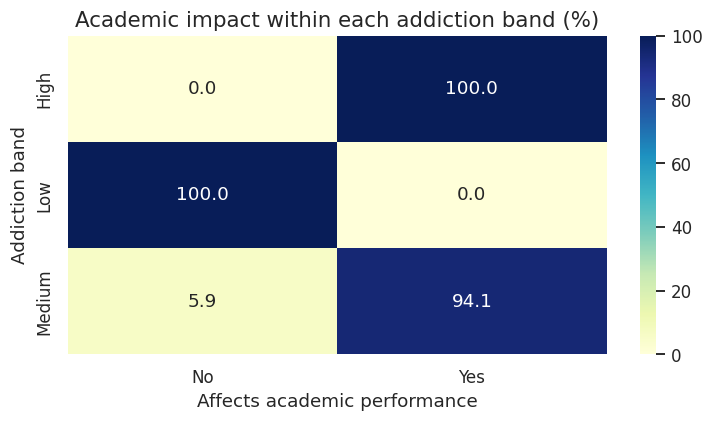

In [14]:
# Summary tables (dashboard-style)

metrics = [
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score",
]
metrics = [c for c in metrics if c in df.columns]

if "Addiction_Band" in df.columns:
    display(
        df.groupby("Addiction_Band")[metrics]
        .agg(["mean", "median", "count"])
        .round(2)
        .sort_index()
    )

if "Usage_Band" in df.columns:
    display(
        df.groupby("Usage_Band")[metrics]
        .agg(["mean", "median", "count"])
        .round(2)
        .sort_index()
    )

# Cross-tab: Addiction band vs Academic impact (percentages)
if all(c in df.columns for c in ["Addiction_Band", "Affects_Academic_Performance"]):
    ct = pd.crosstab(df["Addiction_Band"], df["Affects_Academic_Performance"], normalize="index") * 100
    display(ct.round(1))

    plt.figure(figsize=(7, 4))
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title("Academic impact within each addiction band (%)")
    plt.xlabel("Affects academic performance")
    plt.ylabel("Addiction band")
    plt.tight_layout()
    plt.show()